In [5]:
import torch
from datasets import load_dataset
from transformers import AutoTokenizer
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
import time
import matplotlib.pyplot as plt

# Charger dataset
dataset = load_dataset("imdb")
df = pd.DataFrame(dataset['train'])
df_test = pd.DataFrame(dataset['test'])

# Limiter pour rapidité
df = df.sample(5000, random_state=42)
df_test = df_test.sample(1000, random_state=42)

# Splits
train_texts, val_texts, train_labels, val_labels = train_test_split(df['text'], df['label'], test_size=0.2, random_state=42)
test_texts, test_labels = df_test['text'], df_test['label']

# Fonction pour tokeniser (adaptée par modèle)
def tokenize(texts, tokenizer, max_length=128):
    return tokenizer(texts, padding=True, truncation=True, max_length=max_length, return_tensors="pt")

In [6]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import os

# Optionnel : Désactiver explicitement wandb si needed
os.environ["WANDB_DISABLED"] = "true"

def train_bert(seed):
    torch.manual_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
    model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

    train_enc = tokenize(train_texts.tolist(), tokenizer)
    val_enc = tokenize(val_texts.tolist(), tokenizer)
    test_enc = tokenize(test_texts.tolist(), tokenizer)

    class IMDbDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __getitem__(self, idx):
            item = {key: val[idx] for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item
        def __len__(self):
            return len(self.labels)

    train_dataset = IMDbDataset(train_enc, train_labels.tolist())
    val_dataset = IMDbDataset(val_enc, val_labels.tolist())
    test_dataset = IMDbDataset(test_enc, test_labels.tolist())

    training_args = TrainingArguments(
        output_dir="./results_bert", num_train_epochs=3, per_device_train_batch_size=16,
        per_device_eval_batch_size=16, warmup_steps=500, weight_decay=0.01,
        logging_dir="./logs_bert", eval_strategy="epoch", seed=seed,
        report_to="none"  # Désactive wandb et autres loggers externes
    )

    trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset)

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # Inférence
    start_inf = time.time()
    preds = trainer.predict(test_dataset).predictions.argmax(-1)
    inf_time = (time.time() - start_inf) / len(test_texts)

    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds)

    return acc, f1, train_time, inf_time

# Exécuter 3 runs
bert_results = [train_bert(seed) for seed in [42, 43, 44]]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.327768
2,0.445500,0.379137
3,0.445500,0.443968


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.312914
2,0.448100,0.339940
3,0.448100,0.446392


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss
1,No log,0.363044
2,0.434600,0.341153
3,0.434600,0.442071


In [7]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments

def train_gpt2(seed):
    torch.manual_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained("gpt2")
    tokenizer.pad_token = tokenizer.eos_token  # GPT-2 n'a pas de pad_token par défaut
    model = AutoModelForSequenceClassification.from_pretrained("gpt2", num_labels=2)
    model.config.pad_token_id = tokenizer.pad_token_id

    train_enc = tokenize(train_texts.tolist(), tokenizer)
    val_enc = tokenize(val_texts.tolist(), tokenizer)
    test_enc = tokenize(test_texts.tolist(), tokenizer)

    class IMDbDataset(torch.utils.data.Dataset):
        def __init__(self, encodings, labels):
            self.encodings = encodings
            self.labels = labels
        def __getitem__(self, idx):
            item = {key: val[idx] for key, val in self.encodings.items()}
            item['labels'] = torch.tensor(self.labels[idx])
            return item
        def __len__(self):
            return len(self.labels)

    train_dataset = IMDbDataset(train_enc, train_labels.tolist())
    val_dataset = IMDbDataset(val_enc, val_labels.tolist())
    test_dataset = IMDbDataset(test_enc, test_labels.tolist())

    training_args = TrainingArguments(
        output_dir="./results_gpt2", num_train_epochs=3, per_device_train_batch_size=16,
        per_device_eval_batch_size=16, warmup_steps=500, weight_decay=0.01,
        logging_dir="./logs_gpt2", eval_strategy="epoch", seed=seed
    )

    trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset)

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    start_inf = time.time()
    preds = trainer.predict(test_dataset).predictions.argmax(-1)
    inf_time = (time.time() - start_inf) / len(test_texts)

    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds)

    return acc, f1, train_time, inf_time

gpt2_results = [train_gpt2(seed) for seed in [42, 43, 44]]

Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.363797
2,1.173500,0.468097
3,1.173500,0.355785


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.385741
2,0.526600,0.340610
3,0.526600,0.352944


Some weights of GPT2ForSequenceClassification were not initialized from the model checkpoint at gpt2 and are newly initialized: ['score.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Using the `WANDB_DISABLED` environment variable is deprecated and will be removed in v5. Use the --report_to flag to control the integrations used for logging result (for instance --report_to none).


Epoch,Training Loss,Validation Loss
1,No log,0.379326
2,1.217300,0.363265
3,1.217300,0.337254


In [8]:
from transformers import AutoModelForSeq2SeqLM, Trainer, TrainingArguments
import os

# Désactiver wandb si needed
os.environ["WANDB_DISABLED"] = "true"

def train_t5(seed):
    torch.manual_seed(seed)
    tokenizer = AutoTokenizer.from_pretrained("t5-base")
    model = AutoModelForSeq2SeqLM.from_pretrained("t5-base")

    # Formater inputs
    def format_input(texts):
        return ["sentiment analysis: " + text for text in texts]

    train_inputs = format_input(train_texts.tolist())
    val_inputs = format_input(val_texts.tolist())
    test_inputs = format_input(test_texts.tolist())

    label_map = {0: "negative", 1: "positive"}
    train_tgts = [label_map[label] for label in train_labels]
    val_tgts = [label_map[label] for label in val_labels]
    test_tgts = [label_map[label] for label in test_labels]  # Gardé pour référence, mais non utilisé en inférence

    train_enc = tokenizer(train_inputs, padding=True, truncation=True, max_length=128, return_tensors="pt")
    train_tgt_enc = tokenizer(train_tgts, padding=True, truncation=True, max_length=8, return_tensors="pt")

    val_enc = tokenizer(val_inputs, padding=True, truncation=True, max_length=128, return_tensors="pt")
    val_tgt_enc = tokenizer(val_tgts, padding=True, truncation=True, max_length=8, return_tensors="pt")

    test_enc = tokenizer(test_inputs, padding=True, truncation=True, max_length=128, return_tensors="pt")

    class T5Dataset(torch.utils.data.Dataset):
        def __init__(self, inputs, targets=None):
            self.inputs = inputs
            self.targets = targets
        def __getitem__(self, idx):
            item = {key: val[idx] for key, val in self.inputs.items()}
            if self.targets is not None:
                item['labels'] = self.targets['input_ids'][idx]
            return item
        def __len__(self):
            return len(self.inputs['input_ids'])

    train_dataset = T5Dataset(train_enc, train_tgt_enc)
    val_dataset = T5Dataset(val_enc, val_tgt_enc)
    test_dataset = T5Dataset(test_enc)  # Sans targets pour inférence

    training_args = TrainingArguments(
        output_dir="./results_t5", num_train_epochs=1, per_device_train_batch_size=16,
        per_device_eval_batch_size=16, warmup_steps=500, weight_decay=0.01,
        logging_dir="./logs_t5", eval_strategy="epoch", seed=seed,
        report_to="none"  # Désactive wandb et autres loggers externes
    )

    trainer = Trainer(model=model, args=training_args, train_dataset=train_dataset, eval_dataset=val_dataset)

    start_time = time.time()
    trainer.train()
    train_time = time.time() - start_time

    # Inférence corrigée avec generate
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    test_input_ids = test_enc['input_ids'].to(device)
    test_attention_mask = test_enc['attention_mask'].to(device)

    start_inf = time.time()
    with torch.no_grad():
        outputs = model.generate(input_ids=test_input_ids, attention_mask=test_attention_mask, max_new_tokens=8)
    preds = tokenizer.batch_decode(outputs, skip_special_tokens=True)
    preds = [1 if p.strip().lower() == "positive" else 0 for p in preds]
    inf_time = (time.time() - start_inf) / len(test_texts)

    acc = accuracy_score(test_labels, preds)
    f1 = f1_score(test_labels, preds)

    return acc, f1, train_time, inf_time

t5_results = [train_t5(seed) for seed in [42, 43, 44]]

Epoch,Training Loss,Validation Loss
1,No log,0.173864


Epoch,Training Loss,Validation Loss
1,No log,0.156479


Epoch,Training Loss,Validation Loss
1,No log,0.145157


           Architecture  Accuracy Mean  Accuracy Std   F1 Mean    F1 Std  \
0   Encoder-only (BERT)       0.852000      0.004546  0.847304  0.006917   
1  Decoder-only (GPT-2)       0.868333      0.006182  0.859869  0.006543   
2  Encoder-Decoder (T5)       0.864000      0.002160  0.862989  0.004805   

   Train Time Mean (s)  Train Time Std  Inf Time Mean (s/sample)  Inf Time Std  
0           420.059707       21.429914                  0.007289      0.000087  
1           455.833956       29.267919                  0.007970      0.000107  
2           232.243289       16.761636                  0.008799      0.000132  


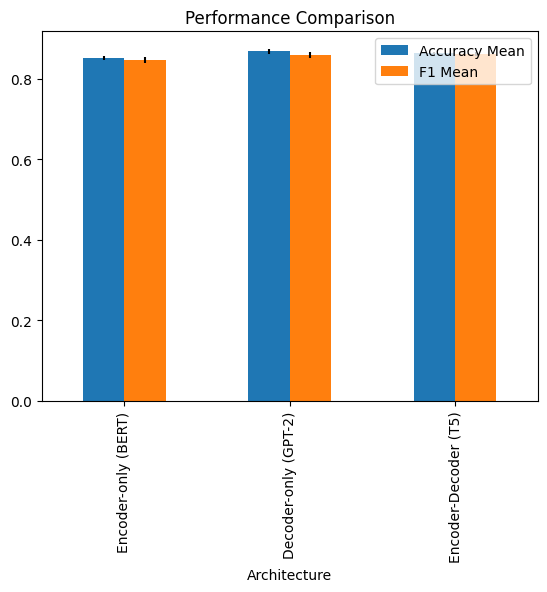

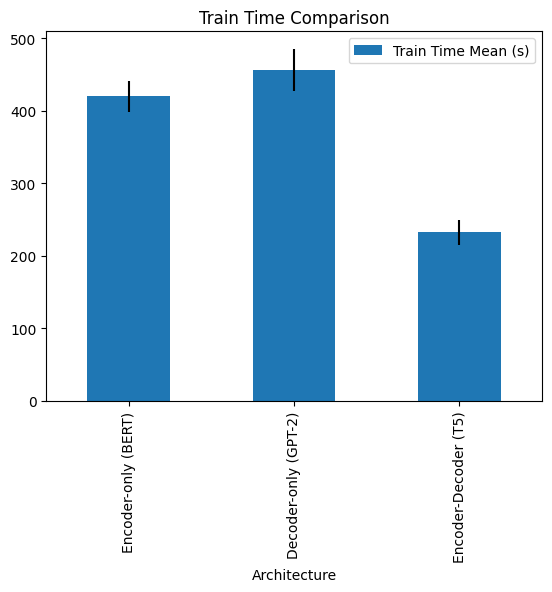

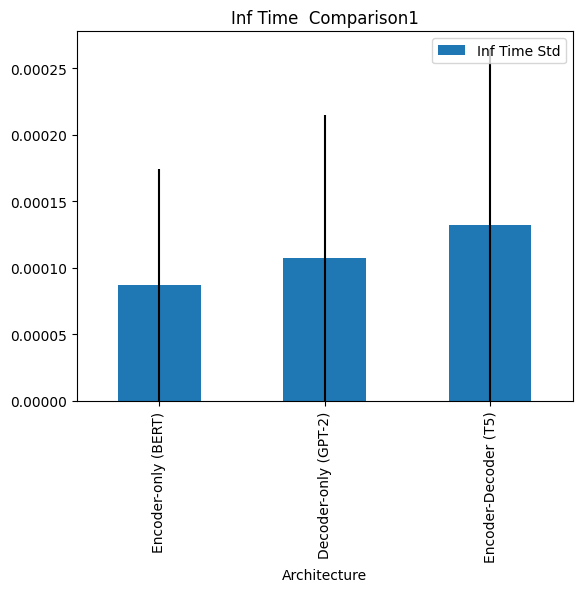

In [9]:
def compile_results(results, name):
    accs = [r[0] for r in results]
    f1s = [r[1] for r in results]
    train_times = [r[2] for r in results]
    inf_times = [r[3] for r in results]
    return {
        'Architecture': name,
        'Accuracy Mean': np.mean(accs), 'Accuracy Std': np.std(accs),
        'F1 Mean': np.mean(f1s), 'F1 Std': np.std(f1s),
        'Train Time Mean (s)': np.mean(train_times), 'Train Time Std': np.std(train_times),
        'Inf Time Mean (s/sample)': np.mean(inf_times), 'Inf Time Std': np.std(inf_times)
    }

all_results = [compile_results(bert_results, 'Encoder-only (BERT)'),
               compile_results(gpt2_results, 'Decoder-only (GPT-2)'),
               compile_results(t5_results, 'Encoder-Decoder (T5)')]

df_results = pd.DataFrame(all_results)
print(df_results)

# Visualisation
df_results.plot(
    x='Architecture',
    y=['Accuracy Mean', 'F1 Mean'],
    kind='bar',
    yerr=df_results[['Accuracy Std', 'F1 Std']].T.values
)
plt.title('Performance Comparison')
plt.show()


df_results.plot(
    x='Architecture',
    y=['Train Time Mean (s)'],
    kind='bar',
    yerr=df_results['Train Time Std'].T.values
)
plt.title('Train Time Comparison')
plt.show()

df_results.plot(
    x='Architecture',
    y=['Inf Time Std'],
    kind='bar',
    yerr=df_results['Inf Time Std'].T.values
)
plt.title('Inf Time  Comparison1')
plt.show()

